# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nfl_data_py as nfl

from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import KFold
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import ParameterSampler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import xgboost as xgb
import shap
import optuna

from ELO import ELO

/Users/iggysiegel/opt/anaconda3/envs/sports_betting/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Import Data

In [2]:
data = pd.read_csv("data/data_engineering_2008_2024_15.csv")
data = data[data["season"] != 2010] # Drop first season due to data engineering

/var/folders/4p/33lbnggs2vz1ffh9zv619nnm0000gn/T/ipykernel_49252/149168617.py:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/data_engineering_2008_2024_15.csv")


In [3]:
features = [
    # General
    'home_elo_prob',
    'div_game',
    'is_playoff',
    'week',
    'away_rest',
    'home_rest',

    # Offense - Home
    'current_win_pctg_home',
    'last_win_pctg_home',
    'streak_home',
    'ats_pctg_home',
    'spread_differential_home',
    'drive_scoring_percentage_off_home',
    'qbr_home',
    'posteam_score_max_off_home',
    'yards_gained_sum_off_home',
    'total_time_of_posession_off_home',
    'total_plays_off_home',
    'complete_pass_sum_off_home',
    'passing_yards_sum_off_home',
    'pass_touchdown_sum_off_home',
    'rush_attempt_sum_off_home',
    'rushing_yards_sum_off_home',
    'rush_touchdown_sum_off_home',
    'third_down_conversion_rate_off_home',
    'penalty_yards_sum_off_home',
    'fumble_lost_sum_off_home',
    'net_turnovers_off_home',
    'qb_hit_sum_off_home',
    'sack_sum_off_home',
    'epa_sum_off_home',

    # Defense - Home
    'posteam_score_max_def_home',
    'yards_gained_sum_def_home',
    'total_plays_def_home',
    'fumble_lost_sum_def_home',
    'net_turnovers_def_home',
    'third_down_conversion_rate_def_home',
    'passing_yards_sum_def_home',
    'pass_touchdown_sum_def_home',
    'rushing_yards_sum_def_home',
    'rush_touchdown_sum_def_home',
    'qb_hit_sum_def_home',
    'sack_sum_def_home',
    'epa_sum_def_home',

    # Offense - Away
    'current_win_pctg_away',
    'last_win_pctg_away',
    'streak_away',
    'ats_pctg_away',
    'spread_differential_away',
    'drive_scoring_percentage_off_away',
    'qbr_away',
    'posteam_score_max_off_away',
    'yards_gained_sum_off_away',
    'total_time_of_posession_off_away',
    'total_plays_off_away',
    'complete_pass_sum_off_away',
    'passing_yards_sum_off_away',
    'pass_touchdown_sum_off_away',
    'rush_attempt_sum_off_away',
    'rushing_yards_sum_off_away',
    'rush_touchdown_sum_off_away',
    'third_down_conversion_rate_off_away',
    'penalty_yards_sum_off_away',
    'fumble_lost_sum_off_away',
    'net_turnovers_off_away',
    'qb_hit_sum_off_away',
    'sack_sum_off_away',
    'epa_sum_off_away',

    # Defense - Away
    'posteam_score_max_def_away',
    'yards_gained_sum_def_away',
    'total_plays_def_away',
    'fumble_lost_sum_def_away',
    'net_turnovers_def_away',
    'third_down_conversion_rate_def_away',
    'passing_yards_sum_def_away',
    'pass_touchdown_sum_def_away',
    'rushing_yards_sum_def_away',
    'rush_touchdown_sum_def_away',
    'qb_hit_sum_def_away',
    'sack_sum_def_away',
    'epa_sum_def_away'
]

# XGBoost / Hyperparameter Tuning

In [4]:
def prepare_data(data, train_seasons, test_seasons, features):
    """
    Prepare data for training and testing.

    Inputs:
        - data: pd.DataFrame, data
        - features: list, features to use
        - train_seasons: list, seasons to train on
        - test_seasons: list, seasons to test on
    Outputs:
        - train_data: pd.DataFrame, training data
        - test_data: pd.DataFrame, testing data
        - X_train: pd.DataFrame, training features
        - y_train: pd.Series, training labels
        - X_test: pd.DataFrame, testing features
        - y_test: pd.Series, testing labels
    """
    train_data = data[data["season"].isin(train_seasons)].dropna(subset = features)
    test_data = data[data["season"].isin(test_seasons)].dropna(subset = features)
    
    X_train = train_data[features]
    y_train = train_data["result"]
    X_test = test_data[features]
    y_test = test_data["result"]

    return train_data, test_data, X_train, y_train, X_test, y_test

In [5]:
def objective(trial, X_train, y_train):
    """
    Objective function for Optuna to optimize XGBoost hyperparameters for regression.

    Inputs:
        - trial: Optuna trial object
        - X_train: pd.DataFrame, Input features
        - y_train: pd.Series, Continuous target labels
    Outputs:
        - score: float, Validation RMSE score
    """
    # Define the hyperparameter search space
    param_grid = {
        "max_depth": trial.suggest_int("max_depth", 1, 5),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 0.1),
        "reg_alpha": trial.suggest_categorical("reg_alpha", [0.0, 0.1, 0.5, 1.0]),
        "reg_lambda": trial.suggest_categorical("reg_lambda", [0.0, 0.1, 0.5, 1.0, 5.0])
    }

    # Initialize the XGBoost model for regression
    model = xgb.XGBRegressor(
        objective = "reg:squarederror",
        eval_metric = "rmse",
        n_estimators = 10000,
        early_stopping_rounds = 10,
        **param_grid
    )

    # 5-fold cross validation
    kf = KFold(n_splits = 5)
    scores = []
    early_stopping = []
    for train_index, val_index in kf.split(X_train):
        X_t, X_v = X_train.iloc[train_index], X_train.iloc[val_index]
        y_t, y_v = y_train.iloc[train_index], y_train.iloc[val_index]
        model.fit(
            X_t,
            y_t,
            eval_set = [(X_v, y_v)],
            verbose = False
        )
        preds = model.predict(X_v)
        scores.append(metrics.root_mean_squared_error(y_v, preds))
        early_stopping.append(model.best_iteration)
    trial.set_user_attr("early_stopping", int(sum(early_stopping) / len(early_stopping)))

    # Return the mean validation RMSE
    return sum(scores) / len(scores)

In [6]:
def tune_hyperparameters(X_train, y_train, n_trials):
    """
    Run Optuna hyperparameter tuning.

    Inputs:
        - X_train: pd.DataFrame, Input features
        - y_train: pd.Series, Input labels
        - n_trials: int, Number of optimization trials
    Output:
        - study: Optuna study object
    """
    study = optuna.create_study(direction = "minimize")
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials = n_trials)
    return study

In [7]:
def betting_simulation(train_data, test_data, confidence = 1.0):
    """ 
    Simulate betting on games based on model predictions.

    Inputs:
        - train_data: pd.DataFrame, training data
        - test_data: pd.DataFrame, testing data
        - confidence: float, number of standard deviations to define high-confidence bets (default is 1.0)
    Outputs:
        - overall_accuracy: float, overall accuracy of betting strategy
        - total_games: int, total number of games bet on
        
    The function evaluates betting outcomes by comparing model predictions to the spread lines. If the 
    difference between the model predictions and spread lines is greater than the threshold, the function
    bets on the game.
    """
    # Determine threshold for high-confidence bets
    threshold = confidence * np.std(train_data["difference"])

    # Initialize counters
    num_correct_total = 0
    num_incorrect_total = 0
    
    # Iterate through each week
    for week in test_data["week"].unique():
        week_data = test_data[test_data["week"] == week]
        num_correct_week = 0
        num_incorrect_week = 0
        for row in week_data.itertuples():
            if row.difference > threshold:
                if (
                    (row.predictions < row.spread_line and row.result < row.spread_line) or
                    (row.predictions > row.spread_line and row.result > row.spread_line)
                ):                    
                    num_correct_week += 1
                    num_correct_total += 1
                else:
                    num_incorrect_week += 1
                    num_incorrect_total += 1

        # Calculate and print weekly accuracy
        total_week_games = num_correct_week + num_incorrect_week
        if total_week_games > 0:
            weekly_accuracy = num_correct_week / total_week_games
            print(f"Week {week:<2}: {weekly_accuracy:.4f} ({num_correct_week}/{total_week_games})")

    # Calculate and print overall accuracy
    total_games = num_correct_total + num_incorrect_total
    if total_games > 0:
        overall_accuracy = num_correct_total / total_games
        print(f"\nSeason Accuracy: {overall_accuracy:.4f} ({num_correct_total}/{total_games})")

    return overall_accuracy, total_games

In [8]:
def main(data, train_seasons, test_seasons, features, n_trials = 100, confidence = 1.0, shapley = False):
    """ 
    Main function to train a machine learning model for NFL game predictions.

    This function prepares the data, tunes hyperparameters, trains the model, and simulates betting outcomes
    based on the model's predictions.

    Inputs:
        - data: pd.DataFrame, full dataset containing game data
        - train_seasons: list, seasons used for training the model
        - test_seasons: list, seasons used for testing the model
        - features: list, feature columns used for model training and predictions
        - n_trials: int, number of trials for hyperparameter optimization (default is 100)
        - confidence: float, number of standard deviations to define high-confidence bets (default is 1.0)
        - shapley: bool, whether to plot SHAP values (default is False)
    Outputs:
        - train_data: pd.DataFrame, training data with model predictions
        - test_data: pd.DataFrame, testing data with model predictions
        - model: Fit XGBoost model
    """
    # Prepare data
    train_data, test_data, X_train, y_train, X_test, y_test = prepare_data(data, train_seasons, test_seasons, features)

    # Tune hyperparameters
    study = tune_hyperparameters(X_train, y_train, n_trials)
    print("Best Optuna parameters:", study.best_params)
    print("Best Optuna score:", study.best_value)
    print()

    # Fit the model with the best hyperparameters
    model = xgb.XGBRegressor(
        objective = "reg:squarederror",
        eval_metric = "rmse",
        n_estimators = study.best_trial.user_attrs["early_stopping"],
        **study.best_params
    )
    model.fit(X_train, y_train)

    # Store predictions and differences
    train_data["predictions"] = model.predict(X_train)
    train_data["difference"] = abs(train_data["predictions"] - train_data["spread_line"])
    test_data["predictions"] = model.predict(X_test)
    test_data["difference"] = abs(test_data["predictions"] - test_data["spread_line"])

    # Shapley plot
    if shapley:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_train)
        plt.figure(figsize = (20, 12))
        shap.summary_plot(shap_values, X_train, show = True, max_display = 20, plot_type = "violin")
        plt.show()

    # Betting simulation
    _, _ = betting_simulation(train_data, test_data, confidence)

    return train_data, test_data, model

# Performance

In [9]:
N_TRIALS = 100
CONFIDENCE = 2.0

[I 2024-12-26 16:48:39,195] A new study created in memory with name: no-name-efa5c8e4-3715-44a2-84e0-22f348635840
[I 2024-12-26 16:48:39,865] Trial 0 finished with value: 13.480546422978358 and parameters: {'max_depth': 3, 'subsample': 0.5152932418698459, 'colsample_bytree': 0.8559262745606802, 'learning_rate': 0.08423862644006908, 'reg_alpha': 0.5, 'reg_lambda': 0.0}. Best is trial 0 with value: 13.480546422978358.
[I 2024-12-26 16:48:40,499] Trial 1 finished with value: 13.466642475168346 and parameters: {'max_depth': 2, 'subsample': 0.7769202175669208, 'colsample_bytree': 0.9108603138984472, 'learning_rate': 0.09168977063292733, 'reg_alpha': 0.0, 'reg_lambda': 0.5}. Best is trial 1 with value: 13.466642475168346.
[I 2024-12-26 16:48:41,505] Trial 2 finished with value: 13.45167430722133 and parameters: {'max_depth': 2, 'subsample': 0.761577526471814, 'colsample_bytree': 0.7670878286628695, 'learning_rate': 0.03600143210123546, 'reg_alpha': 0.0, 'reg_lambda': 0.5}. Best is trial 2 wi

Best Optuna parameters: {'max_depth': 2, 'subsample': 0.6263480731303744, 'colsample_bytree': 0.7029674757457243, 'learning_rate': 0.09996607593842682, 'reg_alpha': 0.0, 'reg_lambda': 0.5}
Best Optuna score: 13.406979096234727



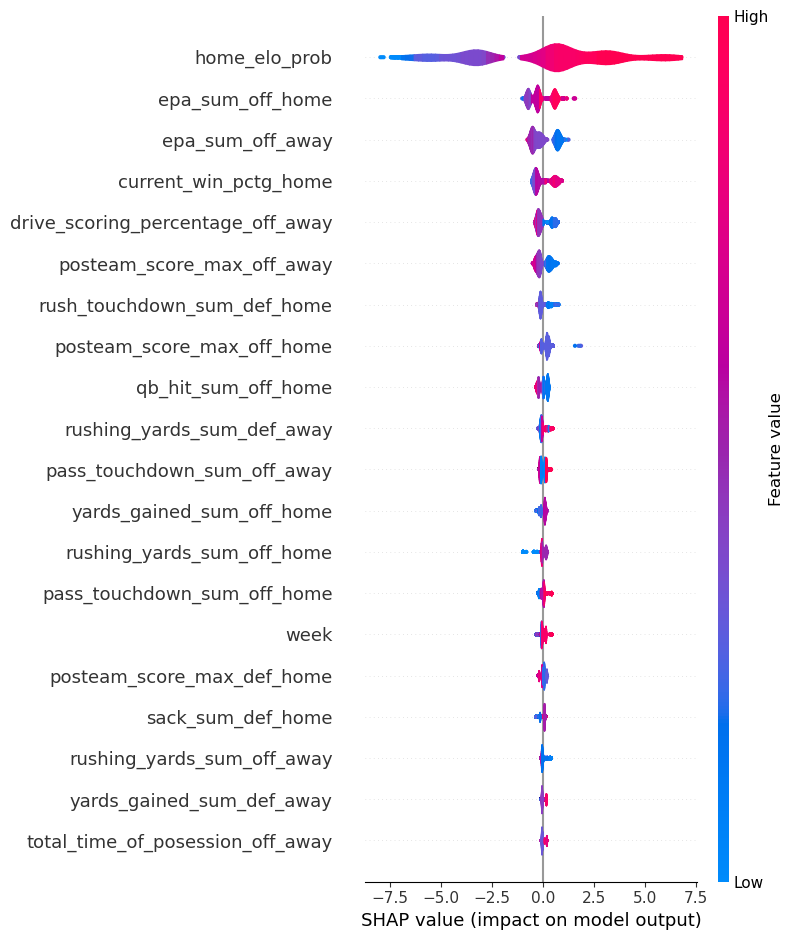

Week 1 : 1.0000 (5/5)
Week 2 : 0.5000 (1/2)
Week 3 : 1.0000 (2/2)
Week 4 : 1.0000 (2/2)
Week 5 : 0.5000 (1/2)
Week 6 : 0.0000 (0/4)
Week 7 : 0.3333 (1/3)
Week 8 : 0.3333 (1/3)
Week 9 : 0.0000 (0/1)
Week 10: 1.0000 (4/4)
Week 11: 0.2500 (1/4)
Week 13: 0.6667 (2/3)
Week 14: 0.5000 (1/2)
Week 15: 0.7500 (3/4)

Season Accuracy: 0.5854 (24/41)


In [10]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
test_seasons = [2024]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-26 16:50:14,909] A new study created in memory with name: no-name-72607f14-4a50-4024-b672-de6babd22096
[I 2024-12-26 16:50:16,236] Trial 0 finished with value: 13.374072034779823 and parameters: {'max_depth': 1, 'subsample': 0.6179199530345829, 'colsample_bytree': 0.7054595348743598, 'learning_rate': 0.02837696532599723, 'reg_alpha': 0.5, 'reg_lambda': 5.0}. Best is trial 0 with value: 13.374072034779823.
[I 2024-12-26 16:50:18,348] Trial 1 finished with value: 13.402623368120294 and parameters: {'max_depth': 1, 'subsample': 0.8675324926681065, 'colsample_bytree': 0.9843161847693529, 'learning_rate': 0.015322766243339923, 'reg_alpha': 0.1, 'reg_lambda': 0.0}. Best is trial 0 with value: 13.374072034779823.
[I 2024-12-26 16:50:19,437] Trial 2 finished with value: 13.361980850161643 and parameters: {'max_depth': 3, 'subsample': 0.7133839459269806, 'colsample_bytree': 0.7330276017000146, 'learning_rate': 0.046387102889445274, 'reg_alpha': 0.0, 'reg_lambda': 5.0}. Best is trial 

Best Optuna parameters: {'max_depth': 2, 'subsample': 0.5991047268363631, 'colsample_bytree': 0.6572484174588382, 'learning_rate': 0.04695078895846947, 'reg_alpha': 0.5, 'reg_lambda': 5.0}
Best Optuna score: 13.335353631414753



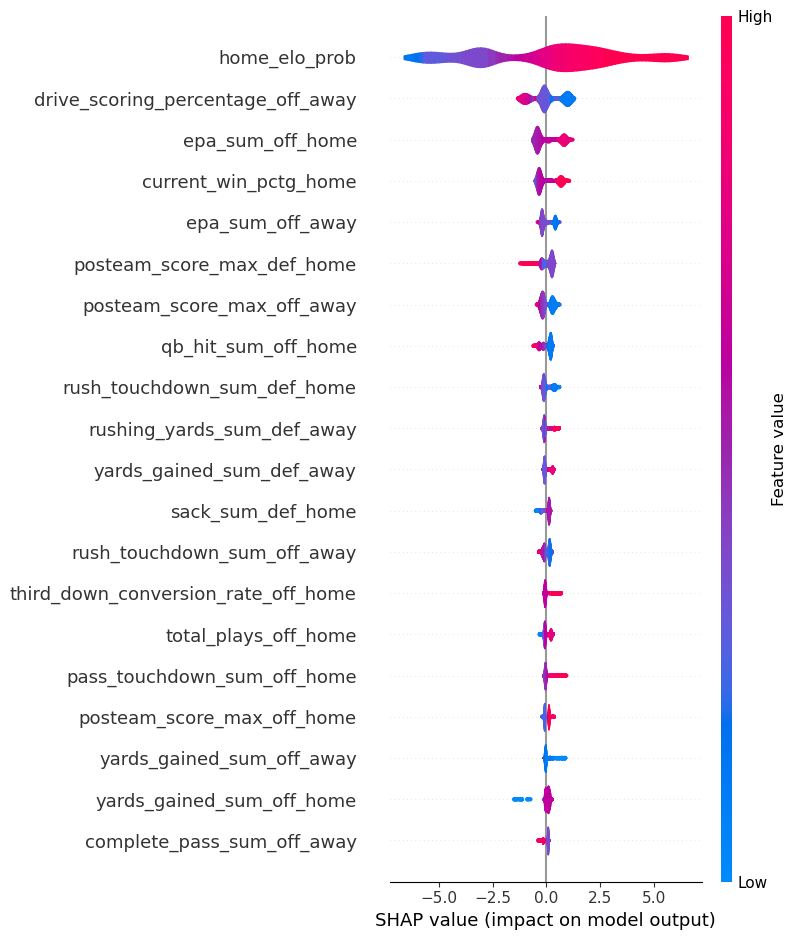

Week 1 : 0.6667 (2/3)
Week 2 : 0.6667 (4/6)
Week 3 : 0.5000 (2/4)
Week 4 : 0.0000 (0/3)
Week 5 : 0.0000 (0/1)
Week 6 : 0.0000 (0/3)
Week 7 : 0.0000 (0/2)
Week 8 : 0.2500 (1/4)
Week 9 : 0.5000 (2/4)
Week 10: 0.5000 (2/4)
Week 11: 1.0000 (4/4)
Week 12: 0.2000 (1/5)
Week 13: 0.0000 (0/2)
Week 14: 0.6667 (2/3)
Week 15: 0.0000 (0/1)
Week 16: 0.3333 (1/3)
Week 17: 0.4444 (4/9)

Season Accuracy: 0.4098 (25/61)


In [11]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
test_seasons = [2023]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-26 16:52:07,724] A new study created in memory with name: no-name-ea3d71b2-8cc2-4ffb-96db-45ec748cb32d
[I 2024-12-26 16:52:08,620] Trial 0 finished with value: 13.497503388069182 and parameters: {'max_depth': 1, 'subsample': 0.5708326794375915, 'colsample_bytree': 0.8472069810554493, 'learning_rate': 0.06455817118673107, 'reg_alpha': 1.0, 'reg_lambda': 0.0}. Best is trial 0 with value: 13.497503388069182.
[I 2024-12-26 16:52:09,846] Trial 1 finished with value: 13.5295167588659 and parameters: {'max_depth': 3, 'subsample': 0.5076337782325475, 'colsample_bytree': 0.7297321560385491, 'learning_rate': 0.03781584311730201, 'reg_alpha': 0.0, 'reg_lambda': 1.0}. Best is trial 0 with value: 13.497503388069182.
[I 2024-12-26 16:52:10,652] Trial 2 finished with value: 13.51872929577777 and parameters: {'max_depth': 3, 'subsample': 0.5642070481434796, 'colsample_bytree': 0.6406882606546618, 'learning_rate': 0.07044090785373056, 'reg_alpha': 0.5, 'reg_lambda': 5.0}. Best is trial 0 wit

Best Optuna parameters: {'max_depth': 2, 'subsample': 0.7335630408224336, 'colsample_bytree': 0.696074091984736, 'learning_rate': 0.07213664376120396, 'reg_alpha': 1.0, 'reg_lambda': 1.0}
Best Optuna score: 13.4631918071445



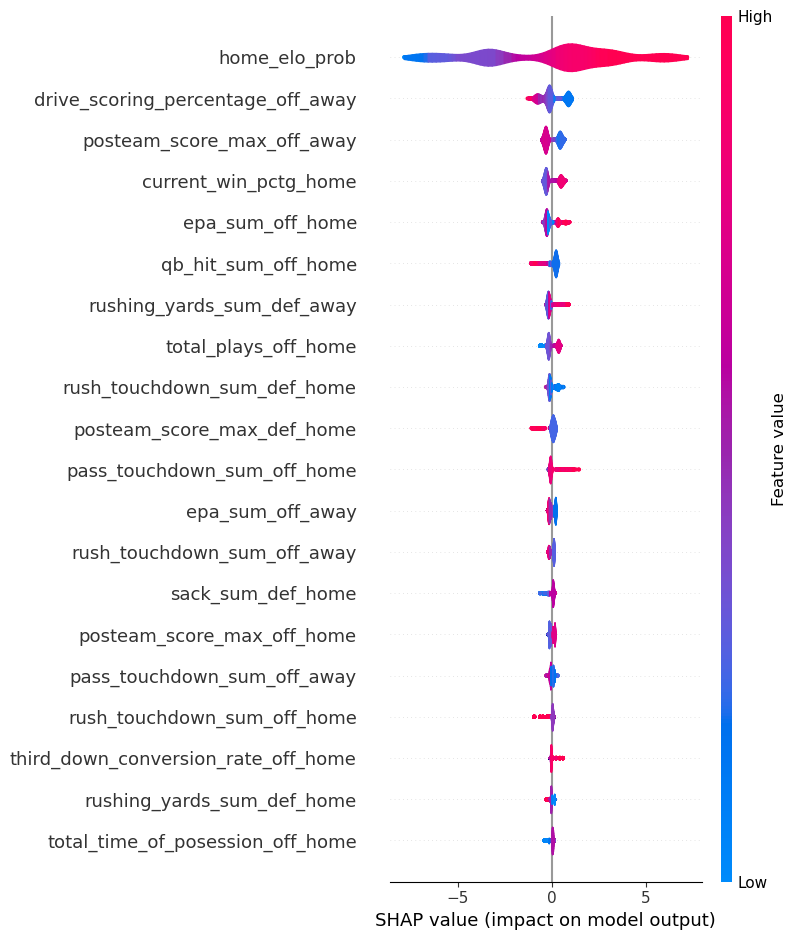

Week 1 : 0.6667 (2/3)
Week 2 : 0.6250 (5/8)
Week 3 : 0.2500 (1/4)
Week 4 : 0.7500 (3/4)
Week 5 : 0.5000 (1/2)
Week 6 : 0.5000 (1/2)
Week 7 : 1.0000 (2/2)
Week 8 : 0.0000 (0/1)
Week 9 : 1.0000 (1/1)
Week 10: 1.0000 (1/1)
Week 11: 0.3333 (1/3)
Week 12: 1.0000 (3/3)
Week 14: 0.5000 (3/6)
Week 15: 0.3333 (1/3)
Week 16: 0.6667 (2/3)
Week 17: 0.6000 (6/10)

Season Accuracy: 0.5893 (33/56)


In [12]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
test_seasons = [2022]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-26 16:55:47,004] A new study created in memory with name: no-name-b7d771f1-d0b7-42e9-825e-301326be1005
[I 2024-12-26 16:55:48,800] Trial 0 finished with value: 13.472299157324652 and parameters: {'max_depth': 4, 'subsample': 0.6731316386668968, 'colsample_bytree': 0.9395681861424787, 'learning_rate': 0.02607697800899595, 'reg_alpha': 0.1, 'reg_lambda': 5.0}. Best is trial 0 with value: 13.472299157324652.
[I 2024-12-26 16:55:50,124] Trial 1 finished with value: 13.468681908839088 and parameters: {'max_depth': 1, 'subsample': 0.656707147059377, 'colsample_bytree': 0.6262290859659991, 'learning_rate': 0.029181033665580777, 'reg_alpha': 1.0, 'reg_lambda': 0.5}. Best is trial 1 with value: 13.468681908839088.
[I 2024-12-26 16:55:50,881] Trial 2 finished with value: 13.464181211307727 and parameters: {'max_depth': 1, 'subsample': 0.8755185999138275, 'colsample_bytree': 0.8599793570520233, 'learning_rate': 0.08424513462040152, 'reg_alpha': 0.1, 'reg_lambda': 5.0}. Best is trial 2 

Best Optuna parameters: {'max_depth': 1, 'subsample': 0.5795009915887372, 'colsample_bytree': 0.541931394620555, 'learning_rate': 0.07179394791709563, 'reg_alpha': 0.1, 'reg_lambda': 5.0}
Best Optuna score: 13.408715246569448



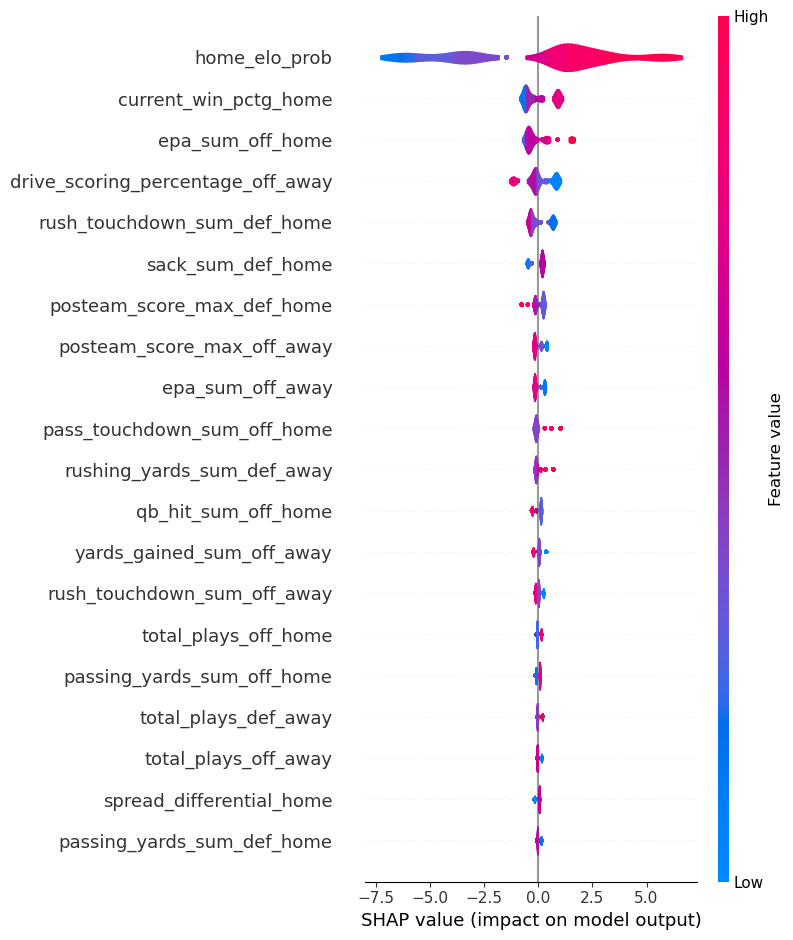

Week 1 : 0.5000 (3/6)
Week 2 : 0.3333 (1/3)
Week 3 : 0.3333 (1/3)
Week 4 : 0.0000 (0/1)
Week 5 : 1.0000 (2/2)
Week 6 : 0.0000 (0/2)
Week 7 : 0.6667 (2/3)
Week 8 : 0.7500 (3/4)
Week 9 : 1.0000 (4/4)
Week 10: 0.0000 (0/1)
Week 11: 0.6667 (2/3)
Week 12: 0.5000 (2/4)
Week 13: 0.0000 (0/1)
Week 14: 0.2500 (1/4)
Week 15: 0.5714 (4/7)
Week 16: 0.4286 (3/7)
Week 17: 0.4000 (4/10)

Season Accuracy: 0.4923 (32/65)


In [13]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
test_seasons = [2021]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-26 16:57:39,908] A new study created in memory with name: no-name-c6067376-456d-4a71-83c8-de93f315f40b
[I 2024-12-26 16:57:45,112] Trial 0 finished with value: 13.636645930228426 and parameters: {'max_depth': 5, 'subsample': 0.9565211750300123, 'colsample_bytree': 0.6607004898006614, 'learning_rate': 0.006384930433708214, 'reg_alpha': 0.5, 'reg_lambda': 5.0}. Best is trial 0 with value: 13.636645930228426.
[I 2024-12-26 16:58:04,322] Trial 1 finished with value: 13.620755601124007 and parameters: {'max_depth': 1, 'subsample': 0.8917100460186786, 'colsample_bytree': 0.922963431398875, 'learning_rate': 0.0009094574323861784, 'reg_alpha': 0.1, 'reg_lambda': 5.0}. Best is trial 1 with value: 13.620755601124007.
[I 2024-12-26 16:58:06,236] Trial 2 finished with value: 13.637524375868802 and parameters: {'max_depth': 5, 'subsample': 0.6634205764688168, 'colsample_bytree': 0.5618837909695811, 'learning_rate': 0.022518745874697755, 'reg_alpha': 0.1, 'reg_lambda': 1.0}. Best is trial

Best Optuna parameters: {'max_depth': 2, 'subsample': 0.6158707129353926, 'colsample_bytree': 0.6738674052650387, 'learning_rate': 0.06026548309073384, 'reg_alpha': 1.0, 'reg_lambda': 0.5}
Best Optuna score: 13.512172352468795



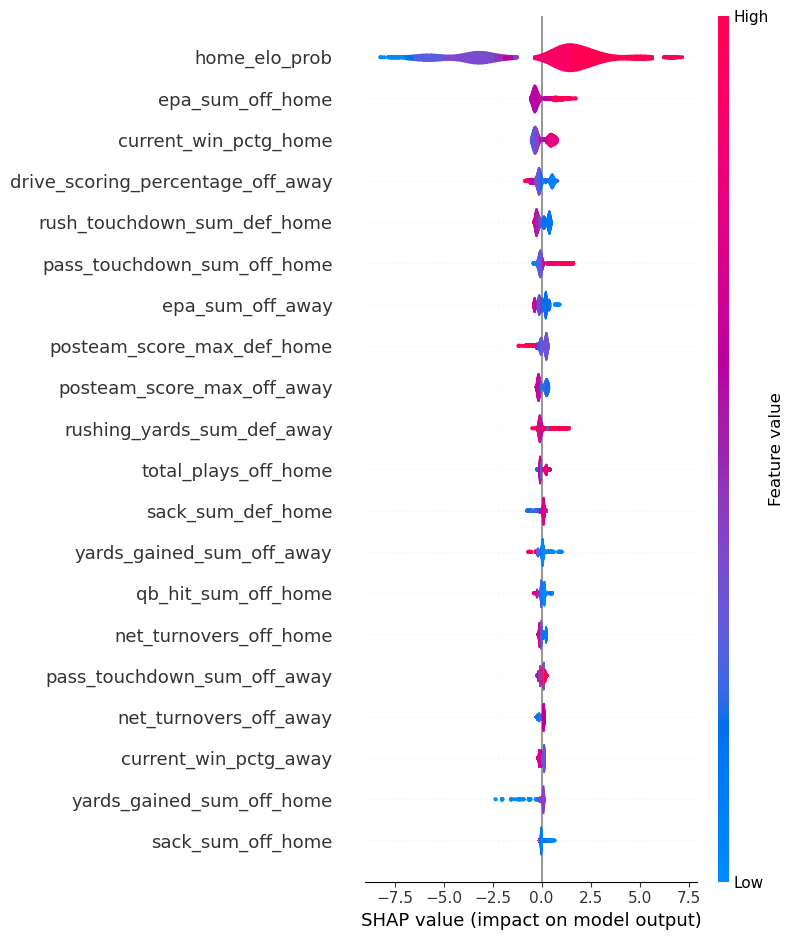

Week 1 : 0.3333 (1/3)
Week 2 : 0.7500 (3/4)
Week 3 : 0.0000 (0/3)
Week 4 : 0.5000 (1/2)
Week 5 : 1.0000 (2/2)
Week 6 : 0.3333 (1/3)
Week 7 : 0.0000 (0/1)
Week 8 : 0.5000 (2/4)
Week 9 : 0.5000 (1/2)
Week 10: 0.0000 (0/3)
Week 11: 1.0000 (3/3)
Week 12: 0.7500 (3/4)
Week 13: 0.6667 (2/3)
Week 14: 0.2500 (1/4)
Week 15: 1.0000 (3/3)
Week 16: 0.7500 (3/4)
Week 17: 0.6667 (4/6)
Week 18: 0.6667 (2/3)

Season Accuracy: 0.5614 (32/57)


In [14]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
test_seasons = [2020]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-26 16:59:42,791] A new study created in memory with name: no-name-00977ce5-4fe2-4aca-82c1-2e0bb1469b89
[I 2024-12-26 16:59:43,602] Trial 0 finished with value: 13.518218066597408 and parameters: {'max_depth': 1, 'subsample': 0.9609752644983323, 'colsample_bytree': 0.5566501446234564, 'learning_rate': 0.051426777161384225, 'reg_alpha': 0.5, 'reg_lambda': 0.0}. Best is trial 0 with value: 13.518218066597408.
[I 2024-12-26 16:59:44,555] Trial 1 finished with value: 13.693867741382928 and parameters: {'max_depth': 5, 'subsample': 0.6960796021005236, 'colsample_bytree': 0.8224778832401252, 'learning_rate': 0.07108586316238927, 'reg_alpha': 0.5, 'reg_lambda': 0.1}. Best is trial 0 with value: 13.518218066597408.
[I 2024-12-26 17:00:11,546] Trial 2 finished with value: 13.56170763620932 and parameters: {'max_depth': 3, 'subsample': 0.9219363144822716, 'colsample_bytree': 0.7033874621067677, 'learning_rate': 0.0005681076474389242, 'reg_alpha': 1.0, 'reg_lambda': 1.0}. Best is trial 

Best Optuna parameters: {'max_depth': 1, 'subsample': 0.8857300724654632, 'colsample_bytree': 0.5478824858812622, 'learning_rate': 0.044297556120301326, 'reg_alpha': 0.1, 'reg_lambda': 5.0}
Best Optuna score: 13.48454139077663



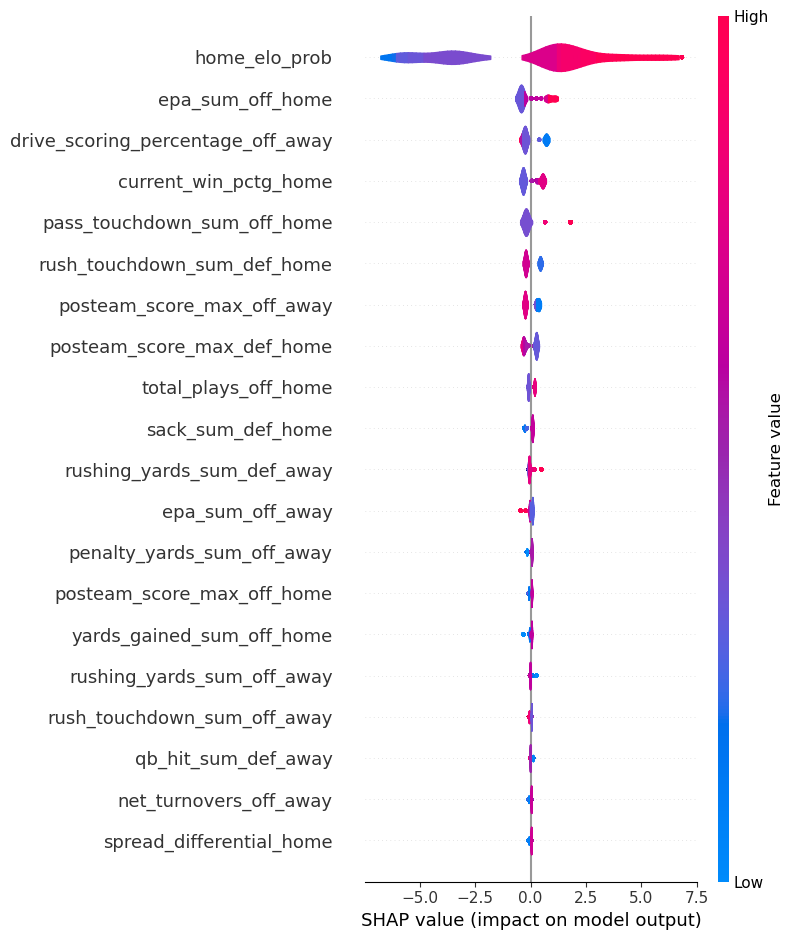

Week 1 : 1.0000 (3/3)
Week 2 : 0.0000 (0/3)
Week 3 : 0.7500 (3/4)
Week 4 : 0.6000 (3/5)
Week 5 : 0.2500 (1/4)
Week 6 : 0.6667 (2/3)
Week 7 : 1.0000 (3/3)
Week 8 : 0.6667 (2/3)
Week 9 : 0.8000 (4/5)
Week 10: 0.5000 (2/4)
Week 11: 0.3333 (1/3)
Week 13: 0.6000 (3/5)
Week 14: 1.0000 (1/1)
Week 15: 0.0000 (0/2)
Week 16: 0.3333 (1/3)
Week 17: 0.5714 (4/7)
Week 18: 0.0000 (0/1)

Season Accuracy: 0.5593 (33/59)


In [15]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
test_seasons = [2019]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-26 17:01:56,523] A new study created in memory with name: no-name-c85e2c87-8ef9-48ed-bda6-b9476e4ed8f4
[I 2024-12-26 17:01:59,167] Trial 0 finished with value: 13.665840912215728 and parameters: {'max_depth': 4, 'subsample': 0.7164208661160226, 'colsample_bytree': 0.5502071490124887, 'learning_rate': 0.008362659089340065, 'reg_alpha': 0.5, 'reg_lambda': 0.0}. Best is trial 0 with value: 13.665840912215728.
[I 2024-12-26 17:02:00,098] Trial 1 finished with value: 13.707709673970545 and parameters: {'max_depth': 5, 'subsample': 0.9958158072351989, 'colsample_bytree': 0.7198882151511778, 'learning_rate': 0.054919327978925764, 'reg_alpha': 0.1, 'reg_lambda': 5.0}. Best is trial 0 with value: 13.665840912215728.
[I 2024-12-26 17:02:06,133] Trial 2 finished with value: 13.668969846365101 and parameters: {'max_depth': 4, 'subsample': 0.738607576892319, 'colsample_bytree': 0.6434216676467648, 'learning_rate': 0.002999074243646398, 'reg_alpha': 0.1, 'reg_lambda': 0.1}. Best is trial 

Best Optuna parameters: {'max_depth': 1, 'subsample': 0.5905284461909655, 'colsample_bytree': 0.6058518034329012, 'learning_rate': 0.0725585547885056, 'reg_alpha': 1.0, 'reg_lambda': 5.0}
Best Optuna score: 13.530158557785754



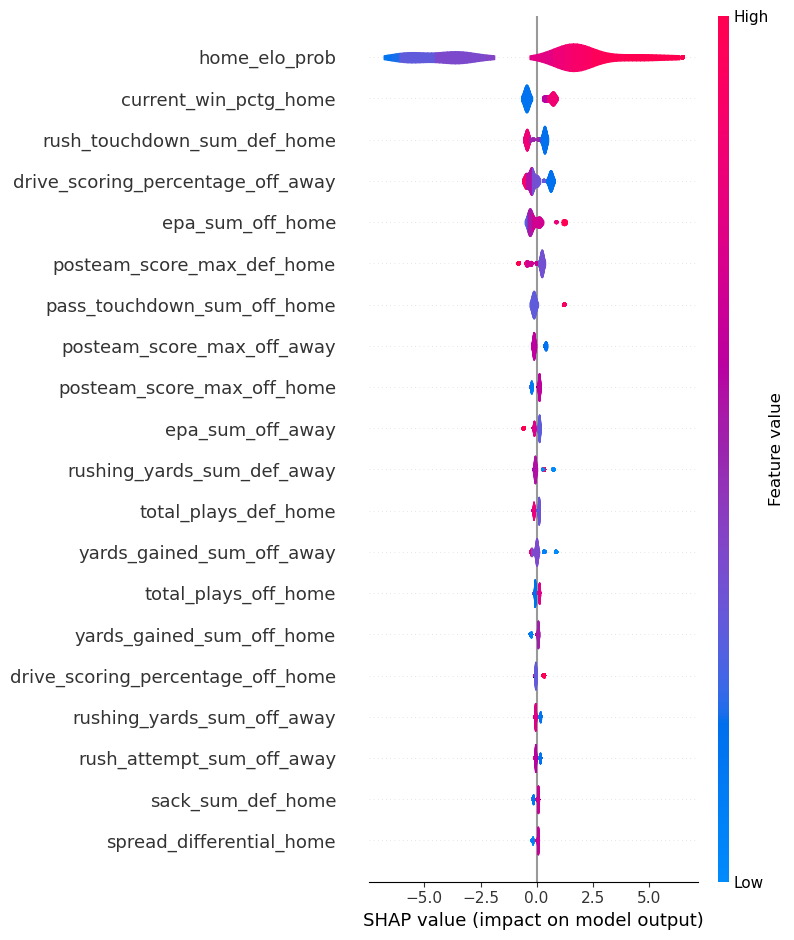

Week 1 : 1.0000 (3/3)
Week 2 : 0.3333 (1/3)
Week 3 : 0.6000 (3/5)
Week 4 : 0.5000 (1/2)
Week 5 : 1.0000 (2/2)
Week 6 : 0.8000 (4/5)
Week 7 : 0.0000 (0/2)
Week 8 : 0.2000 (1/5)
Week 9 : 0.5000 (2/4)
Week 10: 0.0000 (0/1)
Week 11: 0.5000 (1/2)
Week 12: 0.3333 (1/3)
Week 13: 0.6000 (3/5)
Week 14: 0.7500 (3/4)
Week 15: 0.6667 (2/3)
Week 16: 0.3333 (2/6)
Week 17: 0.7500 (3/4)
Week 18: 0.0000 (0/1)

Season Accuracy: 0.5333 (32/60)


In [16]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017]
test_seasons = [2018]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)